# Matplotlib Basics

**What it is:** Importing pandas, numpy, and matplotlib's `pyplot` module — the standard trio for handling data and plotting in Python.

**Why here:** Matplotlib plots numpy arrays, and pandas/numpy are used throughout this notebook to generate the sample data being visualized.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Creating Sample Data

**What it is:** `np.linspace(0, 5, 11)` creates 11 evenly spaced numbers between 0 and 5, and `y = x**2` squares each of them.

**Why here:** This gives a simple, predictable dataset (a parabola) to practice plotting with, before moving on to real-world data.

In [2]:
x = np.linspace(0, 5, 11)
print("x values:", x)

x values: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]


In [3]:
y = x ** 2
print("y values:", y)

y values: [ 0.    0.25  1.    2.25  4.    6.25  9.   12.25 16.   20.25 25.  ]


## Basic Plotting

**What it is:** `plt.plot(x, y)` draws a line graph connecting the (x, y) points; `title()`, `xlabel()`, and `ylabel()` add text labels around the plot.

**Why here:** This is the most basic Matplotlib workflow — plot the data, then label it so a reader knows what they're looking at.

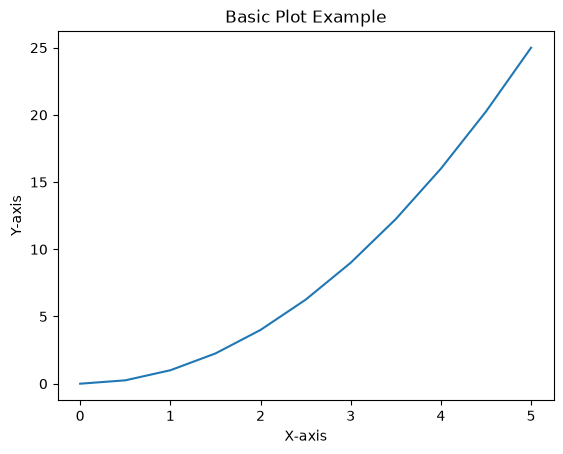

In [4]:
plt.plot(x, y)
plt.title("Basic Plot Example")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

## Subplots in Matplotlib

**What it is:** `plt.subplot(rows, cols, position)` splits one figure into a grid of smaller plots; each plotting call right after it draws into that specific grid position.

**Why here:** To show 4 different plots side by side in a 2x2 grid within a single figure, instead of creating 4 separate figures.

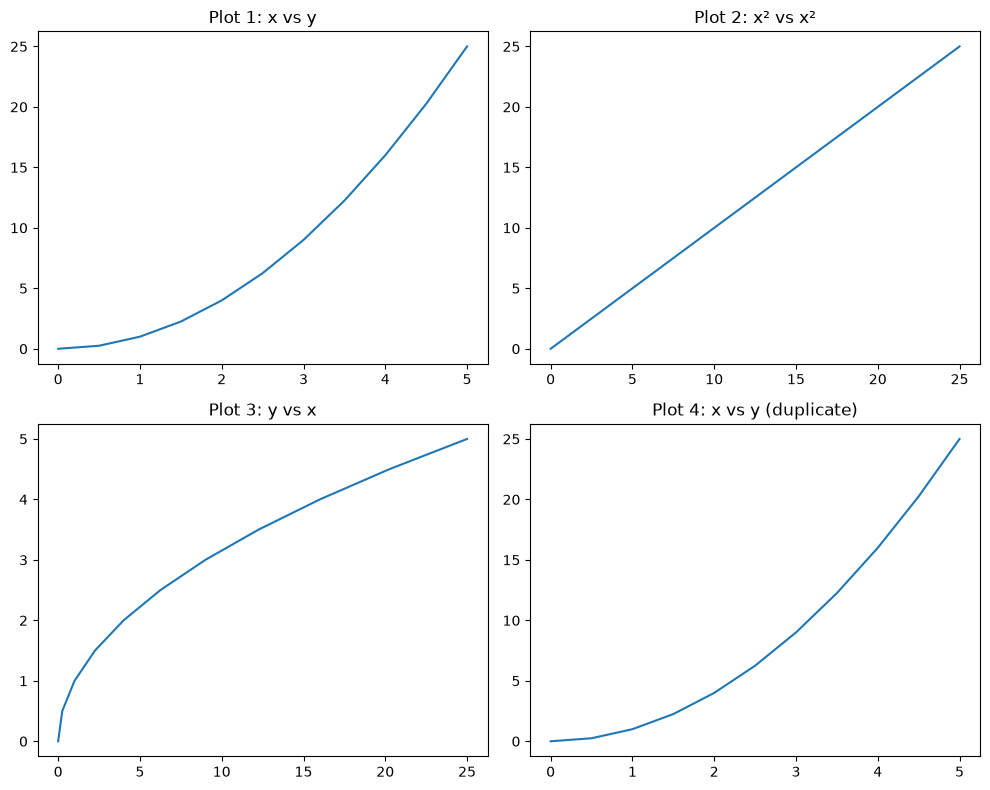

In [5]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(x, y)
plt.title('Plot 1: x vs y')

plt.subplot(2, 2, 2)
plt.plot(x**2, x**2)
plt.title('Plot 2: x² vs x²')

plt.subplot(2, 2, 3)
plt.plot(y, x)
plt.title('Plot 3: y vs x')

plt.subplot(2, 2, 4)
plt.plot(x, y)
plt.title('Plot 4: x vs y (duplicate)')

plt.tight_layout()
plt.show()

## Object Oriented Approach

Matplotlib allows the aspect ratio, DPI and figure size to be specified when the Figure object is created. You can use the figsize and dpi keyword arguments.

- figsize is a tuple of the width and height of the figure in inches
- dpi is the dots-per-inch (pixel per inch)

**What it is:** The 'Object-Oriented' way of plotting — you create a `Figure` object explicitly, then add `Axes` (a plotting area) to it at exact coordinates with `add_axes((left, bottom, width, height))`, where each value is a fraction (0 to 1) of the figure.

**Why here:** To show how to place one small plot INSIDE another (an inset), which the simpler `plt.plot()` style used above can't do — handy for zooming into part of a chart.

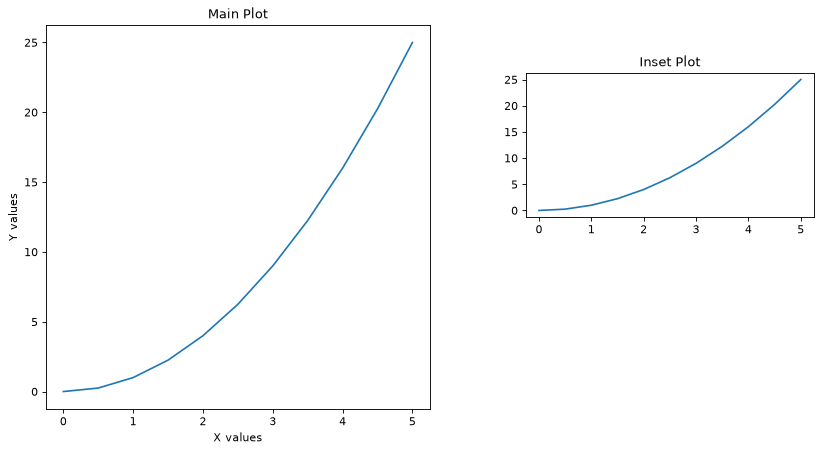

In [6]:
fig = plt.figure(figsize=(12, 6), dpi=80)

# Main plot - using tuple for add_axes (FIXED: was using list before)
axis1 = fig.add_axes((0.1, 0.1, 0.4, 0.8))  # (left, bottom, width, height)
axis1.plot(x, y)
axis1.set_title('Main Plot')
axis1.set_xlabel('X values')
axis1.set_ylabel('Y values')

# Inset plot - using tuple for add_axes (FIXED: was using list before)
axis2 = fig.add_axes((0.6, 0.5, 0.3, 0.3))  # (left, bottom, width, height)
axis2.plot(x, y)
axis2.set_title('Inset Plot')

plt.show()

## Types of Plots

### Scatter Plot

**What it is:** `plt.scatter(x, y)` plots individual (x, y) points as separate dots, instead of connecting them with a line.

**Why here:** It's the natural chart type when you care about each individual point's position rather than the overall trend line.

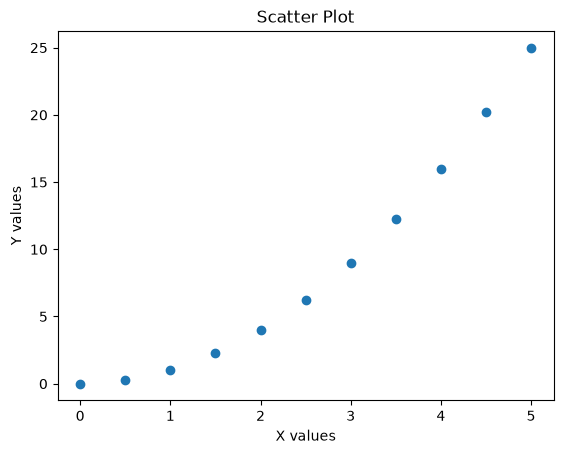

In [7]:
plt.scatter(x, y)
plt.title('Scatter Plot')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.show()

### Histogram

**What it is:** `random.sample()` picks 100 unique random numbers from 1–999, and `plt.hist()` groups them into bins and plots how many values fall into each bin.

**Why here:** A histogram is the go-to chart for seeing the DISTRIBUTION/spread of a set of numbers — this demonstrates it on random data.

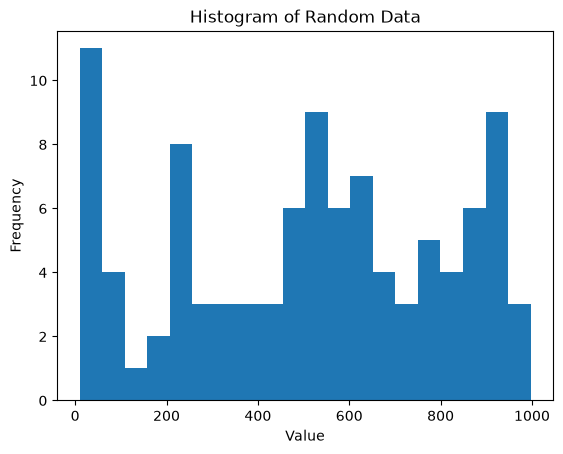

In [8]:
from random import sample

data = sample(range(1, 1000), 100)
plt.hist(data, bins=20)
plt.title('Histogram of Random Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

### Box Plot

**What it is:** `plt.boxplot(x)` draws a box-and-whisker plot, showing the median, the middle 50% of values (the box), and any outliers as separate dots.

**Why here:** Boxplots are a compact way to see a dataset's spread and spot outliers at a glance — shown here on the same `x` array used earlier.

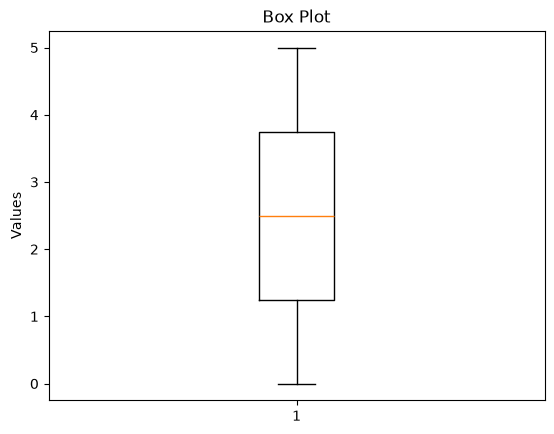

In [9]:
plt.boxplot(x)
plt.title('Box Plot')
plt.ylabel('Values')
plt.show()

## Saving Plots

**What it is:** After building a figure, `plt.savefig('basicplot.png')` writes the current figure to an image file on disk instead of (or in addition to) just displaying it.

**Why here:** To show how to EXPORT a plot as a reusable image file — useful for reports, presentations, or embedding in other documents.

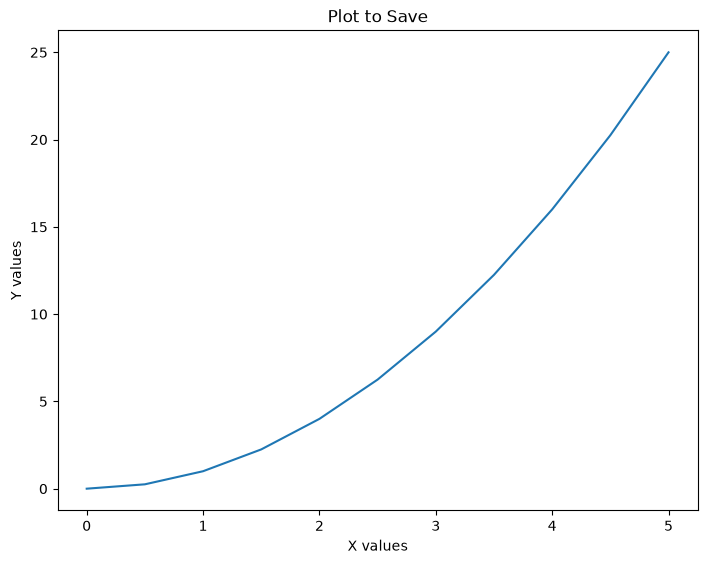

Plot saved as 'basicplot.png'


In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_axes((0.1, 0.1, 0.8, 0.8))  # Using tuple (FIXED: was using list before)
ax.plot(x, y)
ax.set_title('Plot to Save')
ax.set_xlabel('X values')
ax.set_ylabel('Y values')

# Save the figure
plt.savefig("basicplot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'basicplot.png'")

## Working with Images

**What it is:** `matplotlib.image` is the sub-module for reading and working with actual image files (like PNGs/JPEGs), separate from the charting functions used so far.

**Why here:** We're about to load and display a real image, which needs this module instead of `pyplot`'s charting functions.

In [11]:
import matplotlib.image as mpimg
import os

# Check if image file exists, if not create a sample image
if not os.path.exists('data'):
    os.makedirs('data')

# Create a sample image if the file doesn't exist
if not os.path.exists('data/images.jpeg'):
    # Create a simple sample image using numpy
    sample_img = np.random.rand(200, 300, 3)  # Random RGB image
    plt.imsave('data/sample_image.png', sample_img)
    print("Created sample image: data/sample_image.png")
    image_path = 'data/sample_image.png'
else:
    image_path = 'data/images.jpeg'

**What it is:** `mpimg.imread()` reads an image file into a numpy array of pixel values, and `plt.imshow()` displays that array as an image; `plt.axis('off')` hides the x/y coordinate axes.

**Why here:** To demonstrate that Matplotlib can display actual photos too, not just charts — turning the axes off makes it look like a normal image instead of a plot.

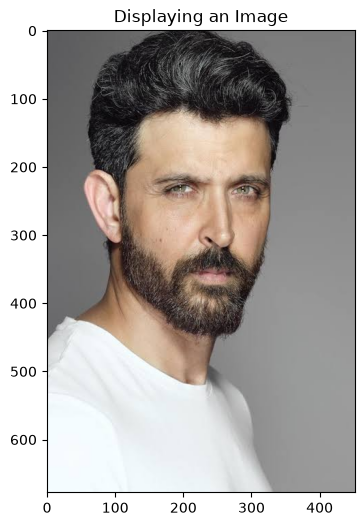

Image shape: (678, 452, 3)


In [12]:
try:
    img = mpimg.imread(image_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title('Displaying an Image')
    # plt.axis('off')  # Uncomment to hide axes
    plt.show()
    print(f"Image shape: {img.shape}")
except FileNotFoundError:
    print(f"Image file not found: {image_path}")
    print("Creating a sample pattern instead...")
    
    # Create a sample pattern
    x_img = np.linspace(0, 10, 100)
    y_img = np.linspace(0, 10, 100)
    X, Y = np.meshgrid(x_img, y_img)
    Z = np.sin(X) * np.cos(Y)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(Z, cmap='viridis')
    plt.title('Sample Pattern')
    plt.colorbar()
    plt.show()

**What it is:** Since an image is just a numpy array of pixels, slicing it like `img[50:200, 100:300]` selects only rows 50–200 and columns 100–300 — effectively cropping the image.

**Why here:** To show that ordinary numpy array slicing works directly on images, letting you crop without any special image-editing function.

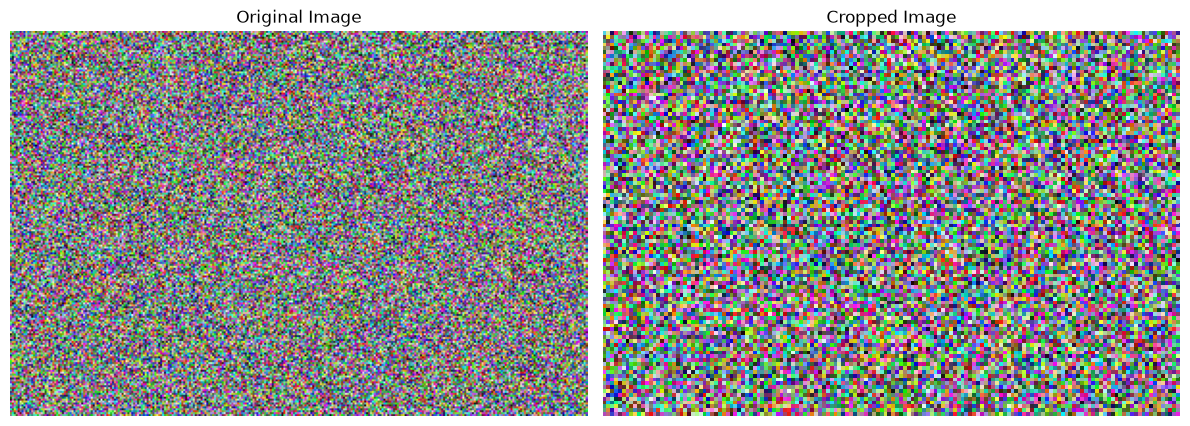

In [13]:
# Create a sample image for cropping demonstration
sample_img = np.random.rand(200, 300, 3)  # Random RGB image

# Crop the image
cropped_img = sample_img[50:150, 100:250]  # crop: rows 50-150, cols 100-250

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(sample_img)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(cropped_img)
ax2.set_title('Cropped Image')
ax2.axis('off')

plt.tight_layout()
plt.show()

## Optional Styling and Customization

### Basic Color Customization

**What it is:** The `color` keyword argument on `plt.plot()` sets a specific line color by name (here, 'green') instead of Matplotlib's default color cycle.

**Why here:** A simple, minimal example of customizing a plot's appearance, leading into the more advanced styling options in the next cells.

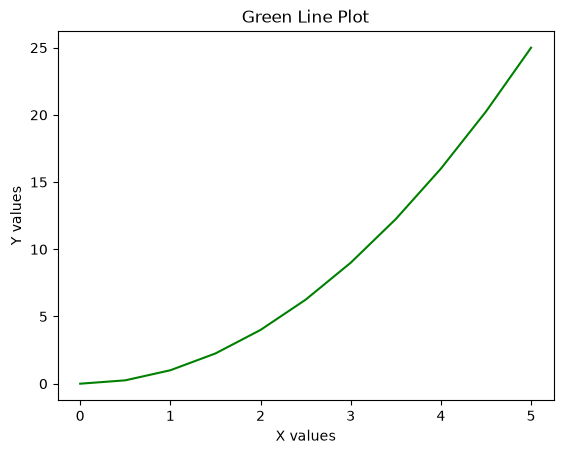

In [14]:
plt.plot(x, y, color="green")
plt.title('Green Line Plot')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.show()

### Advanced Styling Options

**What it is:** Creates a fresh set of 11 evenly spaced x-values from 0 to 5 — the same numbers as the very first `x` array.

**Why here:** Used as the shared x-axis for the big line-styling demo in the next cell, kept as its own variable so it doesn't get mixed up with the original `x`.

In [15]:
xaxis = np.linspace(0, 5, 11)
print("X-axis values:", xaxis)

X-axis values: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]


**What it is:** One figure with many `ax.plot()` calls, each demonstrating a different styling option: `color`, `linewidth`/`lw`, `linestyle`/`ls` (solid, dashed, dotted, or a custom dash pattern via `set_dashes()`), and `marker`/`markersize`/`markerfacecolor`/`markeredgecolor` for the dots on each point.

**Why here:** This is a reference/cheat-sheet cell — it draws the SAME line shifted upward each time (`xaxis+1`, `xaxis+2`, ...) purely so every styling combination shows up as its own separate line, stacked for easy side-by-side comparison.

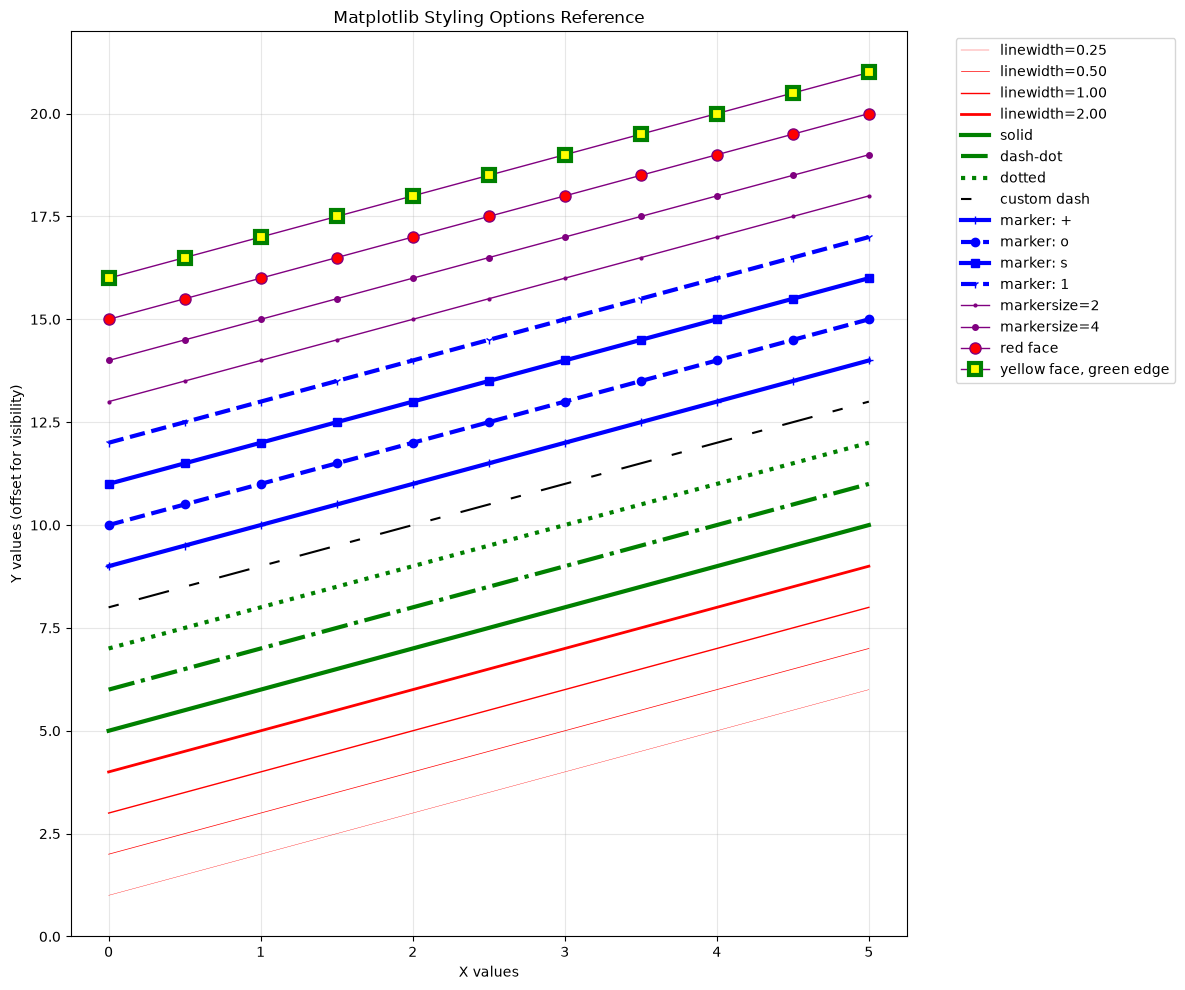

In [16]:
fig, ax = plt.subplots(figsize=(12, 10))

# Line width examples
ax.plot(xaxis, xaxis+1, color="red", linewidth=0.25, label='linewidth=0.25')
ax.plot(xaxis, xaxis+2, color="red", linewidth=0.50, label='linewidth=0.50')
ax.plot(xaxis, xaxis+3, color="red", linewidth=1.00, label='linewidth=1.00')
ax.plot(xaxis, xaxis+4, color="red", linewidth=2.00, label='linewidth=2.00')

# Line style examples
# possible linestyle options '-', '--', '-.', ':', 'steps'
ax.plot(xaxis, xaxis+5, color="green", lw=3, linestyle='-', label='solid')
ax.plot(xaxis, xaxis+6, color="green", lw=3, ls='-.', label='dash-dot')
ax.plot(xaxis, xaxis+7, color="green", lw=3, ls=':', label='dotted')

# Custom dash pattern
line, = ax.plot(xaxis, xaxis+8, color="black", lw=1.50, label='custom dash')
line.set_dashes([5, 10, 15, 10])  # format: line length, space length, ...

# Marker examples
# possible marker symbols: marker = '+', 'o', '*', 's', ',', '.', '1', '2', '3', '4', ...
ax.plot(xaxis, xaxis+ 9, color="blue", lw=3, ls='-', marker='+', label='marker: +')
ax.plot(xaxis, xaxis+10, color="blue", lw=3, ls='--', marker='o', label='marker: o')
ax.plot(xaxis, xaxis+11, color="blue", lw=3, ls='-', marker='s', label='marker: s')
ax.plot(xaxis, xaxis+12, color="blue", lw=3, ls='--', marker='1', label='marker: 1')

# Marker size examples
ax.plot(xaxis, xaxis+13, color="purple", lw=1, ls='-', marker='o', markersize=2, label='markersize=2')
ax.plot(xaxis, xaxis+14, color="purple", lw=1, ls='-', marker='o', markersize=4, label='markersize=4')
ax.plot(xaxis, xaxis+15, color="purple", lw=1, ls='-', marker='o', markersize=8, 
        markerfacecolor="red", label='red face')
ax.plot(xaxis, xaxis+16, color="purple", lw=1, ls='-', marker='s', markersize=8, 
        markerfacecolor="yellow", markeredgewidth=3, markeredgecolor="green", 
        label='yellow face, green edge')

ax.set_xlabel('X values')
ax.set_ylabel('Y values (offset for visibility)')
ax.set_title('Matplotlib Styling Options Reference')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()